In [1]:
!pip install gymnasium[toy_text] matplotlib seaborn numpy pandas -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import gymnasium as gym
import pandas as pd
from collections import defaultdict
import random, time


In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seed()


In [3]:
class QLearningAgent:

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_states  = n_states
        self.n_actions = n_actions
        self.alpha     = alpha
        self.gamma     = gamma
        self.epsilon   = epsilon
        self.Q = np.zeros((n_states, n_actions))

#e-greedy policy
    def select_action(self, state):

        if np.random.rand() < self.epsilon:
          #selecting a random action from the set of actions ( exploring)
            return np.random.randint(self.n_actions)
            #best possible action to take in the particular state
        return np.argmax(self.Q[state]) # Exploiting

    def update(self, s, a, r, s_next, done):

        best_next = 0 if done else np.max(self.Q[s_next]) #?
        td_target = r + self.gamma * best_next
        td_error  = td_target - self.Q[s, a]
        self.Q[s, a] += self.alpha * td_error

    def get_policy(self):

        return np.argmax(self.Q, axis=1)


In [4]:
def train(env_name, agent, n_episodes=2000, max_steps=200, seed=42):

    env = gym.make(env_name)
    rewards, steps_per_ep = [], []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_r, steps = 0, 0

        for _ in range(max_steps):
            action          = agent.select_action(state)
            next_s, r, terminated, truncated, _ = env.step(action)
            done            = terminated or truncated
            agent.update(state, action, r, next_s, done)
            state, total_r, steps = next_s, total_r + r, steps + 1
            if done:
                break

        rewards.append(total_r)
        steps_per_ep.append(steps)

    env.close()
    return np.array(rewards), np.array(steps_per_ep)


In [5]:
def run_multi_seed(env_name, env_params, train_params, seeds=range(10)):

    all_rewards = []
    for seed in seeds:
        set_seed(seed)
        agent = QLearningAgent(**env_params)
        rewards, _ = train(env_name, agent, seed=seed, **train_params)
        all_rewards.append(rewards)
    arr = np.array(all_rewards)
    return arr.mean(axis=0), arr.std(axis=0)

In [6]:
def smooth(arr, window=50):
    return pd.Series(arr).rolling(window, min_periods=1).mean().values

def plot_learning_curve(rewards_dict, title, window=50):

    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
    for (label, (mean_r, std_r)), color in zip(rewards_dict.items(), colors):
        eps = np.arange(len(mean_r))
        sm  = smooth(mean_r, window)
        ax.plot(eps, sm, label=label, color=color, lw=2)
        ax.fill_between(eps,
                        smooth(mean_r - std_r, window),
                        smooth(mean_r + std_r, window),
                        alpha=0.15, color=color)
    ax.set_xlabel('Episode')
    ax.set_ylabel(f'Reward (smoothed, window={window})')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [7]:
class GridWorld:

    def __init__(self, size=4, holes=None, goal_reward=1.0, step_reward=-0.01):
        self.size        = size
        self.n_states    = size * size
        self.n_actions   = 4
        self.holes       = holes or [(1,1),(2,2),(1,3)]
        self.goal        = (size-1, size-1)
        self.goal_reward = goal_reward
        self.step_reward = step_reward
        self._moves      = [(-1,0),(1,0),(0,-1),(0,1)]
        self.reset()

    def _to_state(self, r, c):  return r * self.size + c
    def _to_rc(self, s):        return divmod(s, self.size)

    def reset(self, seed=None):
        self.pos = (0, 0)
        return self._to_state(*self.pos)

    def step(self, action):
        dr, dc   = self._moves[action]
        r, c     = self.pos
        nr, nc   = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
        self.pos = (nr, nc)
        s        = self._to_state(nr, nc)

        if (nr, nc) == self.goal:
            return s, self.goal_reward, True
        if (nr, nc) in self.holes:
            return s, -1.0, True
        return s, self.step_reward, False

def train_gridworld(agent, n_episodes=2000, max_steps=200):
    env = GridWorld()
    rewards = []
    for ep in range(n_episodes):
        s = env.reset()
        total_r = 0
        for _ in range(max_steps):
            a = agent.select_action(s)
            s_next, r, done = env.step(a)
            agent.update(s, a, r, s_next, done)
            s, total_r = s_next, total_r + r
            if done: break
        rewards.append(total_r)
    return np.array(rewards)


In [8]:
def check_bellman(Q, env_name, gamma=0.99, tol=0.1):

    env     = gym.make(env_name)
    errors  = []
    state, _ = env.reset()
    for _ in range(500):
        action = np.argmax(Q[state])
        next_s, r, term, trunc, _ = env.step(action)
        done  = term or trunc
        best  = 0 if done else np.max(Q[next_s])
        error = abs(Q[state, action] - (r + gamma * best))
        errors.append(error)
        state = next_s
        if done:
            state, _ = env.reset()
    env.close()
    mean_err = np.mean(errors)
    print(f"  Bellman check — mean TD error: {mean_err:.4f} "
          f"({'PASS' if mean_err < tol else 'needs more training'})")
    return mean_err


In [9]:
def plot_qvalue_heatmap(Q, env_name, size=4):

    V = np.max(Q, axis=1).reshape(size, size)
    plt.figure(figsize=(5, 4))
    sns.heatmap(V, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'Max Q-value'})
    plt.title(f'State Value Heatmap — {env_name}')
    plt.xlabel('Column'); plt.ylabel('Row')
    plt.tight_layout(); plt.show()


In [10]:
def plot_policy_arrows(Q, size=4, title='Learned Policy'):

    ARROWS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    policy = np.argmax(Q, axis=1).reshape(size, size)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, size); ax.set_ylim(0, size)
    ax.set_xticks(range(size)); ax.set_yticks(range(size))
    ax.grid(True, lw=1.5)
    ax.set_title(title)

    for r in range(size):
        for c in range(size):
            a = policy[r, c]
            ax.text(c + 0.5, size - r - 0.5, ARROWS[a],
                    ha='center', va='center', fontsize=18)
    plt.tight_layout(); plt.show()



Q-Learning
Training on GridWorld 
  Final avg reward (last 100 eps): 0.759


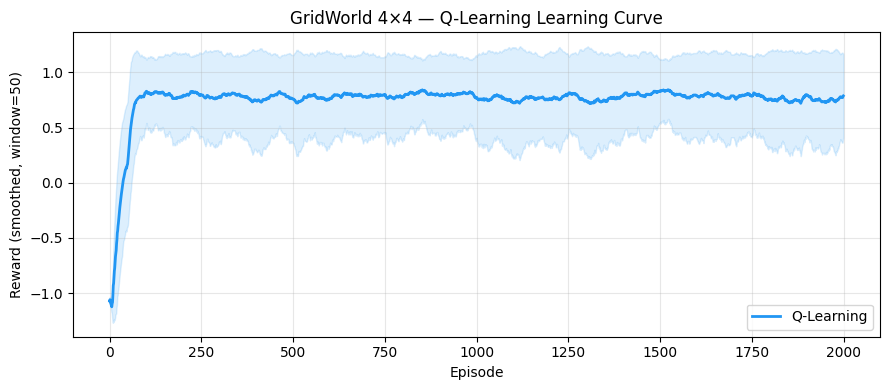

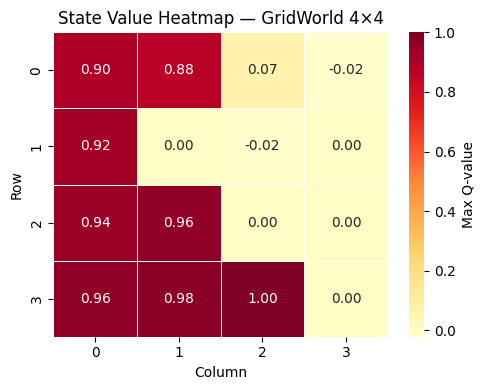

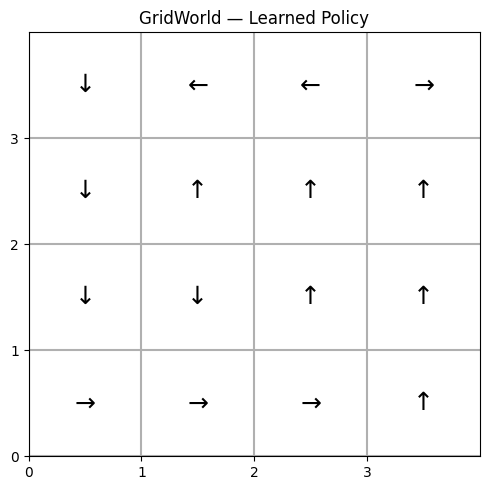

In [11]:
print("Q-Learning")

print("Training on GridWorld ")
gw_rewards_all = []
for seed in range(10):
    set_seed(seed)
    agent_gw = QLearningAgent(n_states=16, n_actions=4,
                              alpha=0.1, gamma=0.99, epsilon=0.1)
    r = train_gridworld(agent_gw, n_episodes=2000)
    gw_rewards_all.append(r)
gw_mean = np.array(gw_rewards_all).mean(axis=0)
gw_std  = np.array(gw_rewards_all).std(axis=0)
print(f"  Final avg reward (last 100 eps): {gw_mean[-100:].mean():.3f}")
plot_learning_curve({'Q-Learning': (gw_mean, gw_std)},
                    'GridWorld 4×4 — Q-Learning Learning Curve')
plot_qvalue_heatmap(agent_gw.Q, 'GridWorld 4×4', size=4)
plot_policy_arrows(agent_gw.Q, size=4, title='GridWorld — Learned Policy')



 Training on FrozenLake-v1...
  Final avg reward (last 100 eps): 0.235
  Bellman check — mean TD error: 0.0415 (PASS)


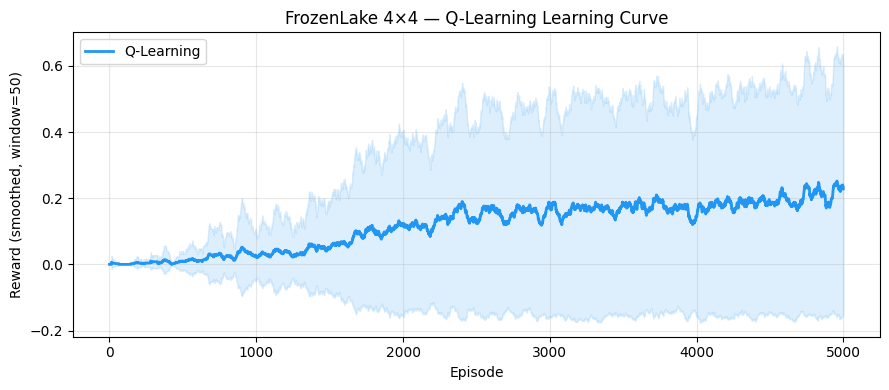

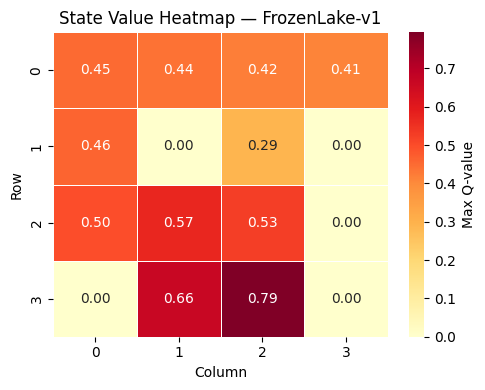

In [12]:
print("\n Training on FrozenLake-v1...")
fl_params  = dict(n_states=16,  n_actions=4, alpha=0.1, gamma=0.99, epsilon=0.2)
fl_train   = dict(n_episodes=5000, max_steps=200)
fl_mean, fl_std = run_multi_seed('FrozenLake-v1', fl_params, fl_train)
print(f"  Final avg reward (last 100 eps): {fl_mean[-100:].mean():.3f}")


set_seed(0)
agent_fl = QLearningAgent(**fl_params)
train('FrozenLake-v1', agent_fl, **fl_train)
check_bellman(agent_fl.Q, 'FrozenLake-v1')
plot_learning_curve({'Q-Learning': (fl_mean, fl_std)},
                    'FrozenLake 4×4 — Q-Learning Learning Curve')
plot_qvalue_heatmap(agent_fl.Q, 'FrozenLake-v1', size=4)




Training on CliffWalking-v1 ...
  Final avg reward (last 100 eps): -50.559
  Bellman check — mean TD error: 0.0000 (PASS)


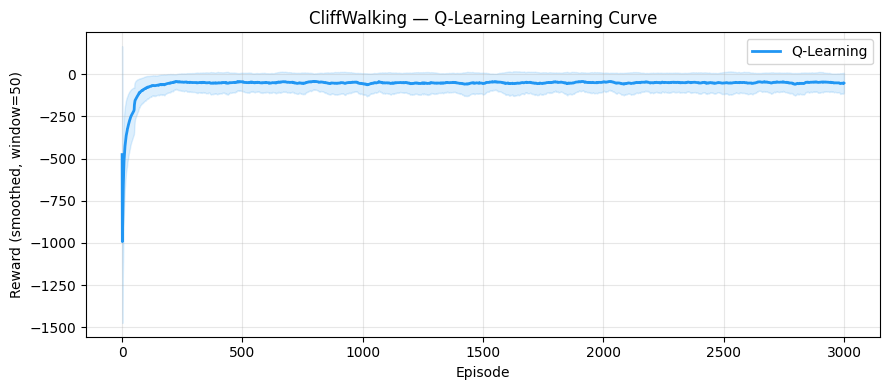

In [13]:
print("\nTraining on CliffWalking-v1 ...")
cw_params = dict(n_states=48, n_actions=4, alpha=0.1, gamma=0.99, epsilon=0.1)
cw_train  = dict(n_episodes=3000, max_steps=500)
cw_mean, cw_std = run_multi_seed('CliffWalking-v1', cw_params, cw_train)
print(f"  Final avg reward (last 100 eps): {cw_mean[-100:].mean():.3f}")

set_seed(0)
agent_cw = QLearningAgent(**cw_params)
train('CliffWalking-v1', agent_cw, **cw_train)
check_bellman(agent_cw.Q, 'CliffWalking-v1', tol=1.0)
plot_learning_curve({'Q-Learning': (cw_mean, cw_std)},
                    'CliffWalking — Q-Learning Learning Curve')

 Training on Taxi-v3 ...
  Final avg reward (last 100 eps): -4.640
  Bellman check — mean TD error: 0.0300 (PASS)


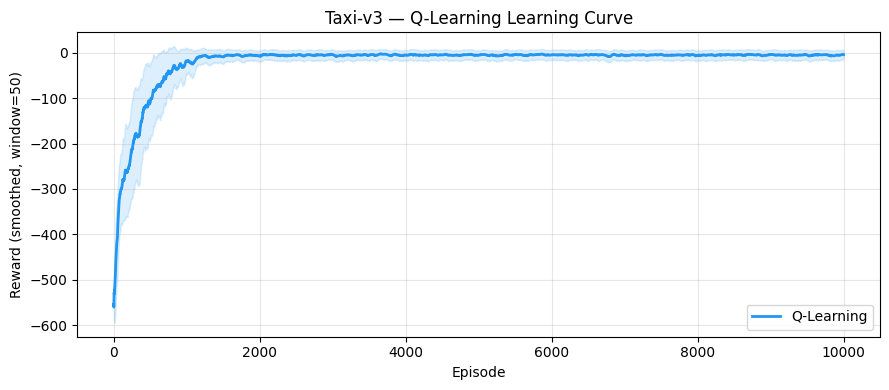

In [14]:
print(" Training on Taxi-v3 ...")
tx_params = dict(n_states=500, n_actions=6, alpha=0.1, gamma=0.99, epsilon=0.2)
tx_train  = dict(n_episodes=10000, max_steps=300)
tx_mean, tx_std = run_multi_seed('Taxi-v3', tx_params, tx_train)
print(f"  Final avg reward (last 100 eps): {tx_mean[-100:].mean():.3f}")

set_seed(0)
agent_tx = QLearningAgent(**tx_params)
train('Taxi-v3', agent_tx, **tx_train)
check_bellman(agent_tx.Q, 'Taxi-v3', tol=2.0)
plot_learning_curve({'Q-Learning': (tx_mean, tx_std)},
                    'Taxi-v3 — Q-Learning Learning Curve')


In [15]:

print("PHASE 1 SUMMARY")

results = {
    'Environment':    ['GridWorld 4×4', 'FrozenLake 4×4', 'CliffWalking', 'Taxi-v3'],
    'Episodes':       [2000, 5000, 3000, 10000],
    'Final Reward':   [f"{gw_mean[-100:].mean():.3f}",
                       f"{fl_mean[-100:].mean():.3f}",
                       f"{cw_mean[-100:].mean():.3f}",
                       f"{tx_mean[-100:].mean():.3f}"],
}
df = pd.DataFrame(results)
print(df.to_string(index=False))
print("\n Q-tables saved as agent_gw, agent_fl, agent_cw, agent_tx")

PHASE 1 SUMMARY
   Environment  Episodes Final Reward
 GridWorld 4×4      2000        0.759
FrozenLake 4×4      5000        0.235
  CliffWalking      3000      -50.559
       Taxi-v3     10000       -4.640

 Q-tables saved as agent_gw, agent_fl, agent_cw, agent_tx
